In [12]:
import numpy as np
from cellular_automata.cellular_automata import CellularAutomata as ca

from PIL import Image, ImageSequence

# Game of life model

MovieWriter imagemagick unavailable; using Pillow instead.


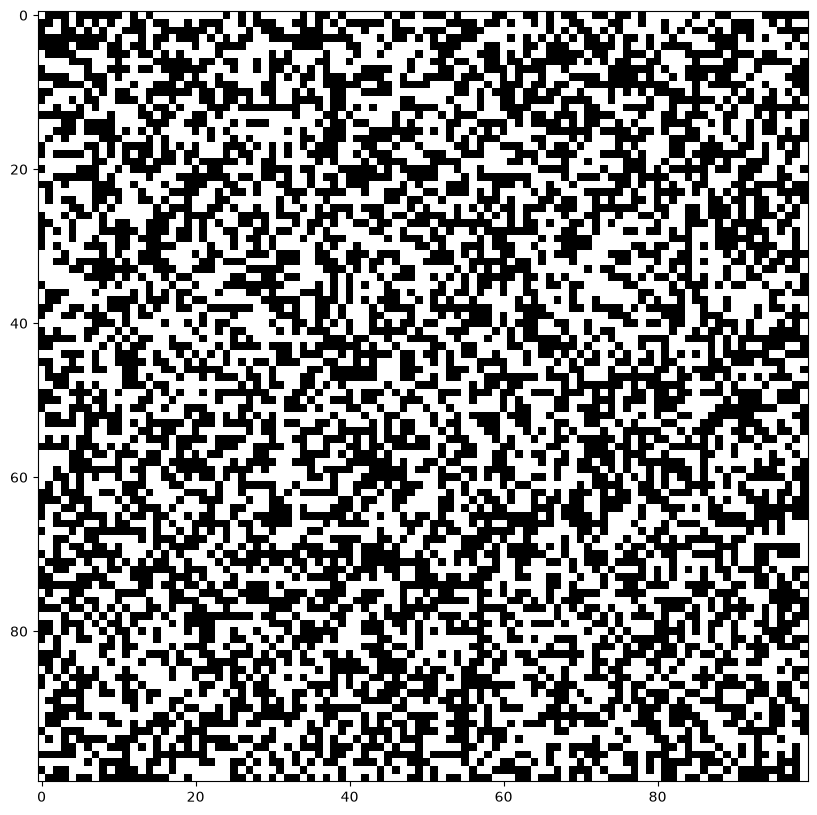

In [1]:
import numpy as np
from cellular_automata.cellular_automata import CellularAutomata as ca

# difining the ca object with parameters
model = ca(width=100,height=100, input_array='', generations=100, save_image=True,save_movie=False,
                  save_data=True, filename='data/gof_test')


# game of life model
# we start with this model here

model.game_of_life()

we have what we want... hopefully, now we must pursue the framing of the gif
our ca library save the evolution as a gif, we should use pillow for obtaining the data

I also think that we should study better our library, because it implements very good things

after a lot of time we have a automa-black, lattice-white model


So...
it is better to manipulate the gif, with pillow I think,
since we have the data saved as a gif

In [2]:
data = np.load("data/gof_test.npy")

# slicing dei dati dell'automa, abbiamo un tensore 3 dimensionale
# frame, riga, colonna
print(data.shape)

(101, 100, 100)


### pipeline

In [3]:
# at the moment the function runs just game of life


def run_CA(ca_model, iterations, w, h, image, movie, data, filename, rule):
    """
        THIS FUNCTION RUNS THE MODEL AND GENERATES ITERATIONS
        TODO: complete the function with all the ca models

        input: 
            ca_model: model to use for the simulation
            iterations: number of iterations
            w, h: width, height of the lattice
            image: boolean -> do we want to save?
            movie,
            data
            filename: path where we want to salve data
        
            output:
                model_test_ gif,
                model_test npy
    """

    # creating the object
    model = ca(width=w,height=h, input_array='', generations=iterations, save_image=image,save_movie=movie, 
               save_data=data, filename=filename, given_rule = rule)

    # runs game of life
    if ca_model == "gof":
        model.game_of_life()
    

In [4]:
def convert_to_image(data, frame):
    """
    This function returns the image based on the data obtained by the simulation and the data passed 

    Args:
        data numpy_array: _description_
        frame int: _description_

    Return:
        image: gif with pillow
    """
    
    grid = data[frame, :]

    img = Image.fromarray((grid*255).astype(np.uint8))
    
    return img

In [5]:
def data_obtainer(movie, neigh):
    """
    This function, given a movie of the evolution as a gif format, 
    return us all the frames saved by name

    Args:
        movie (gif): the animation of the cellular automata, path to it
        path: path of the directory
        
    Return:
        frames: all the frames saved in a array 
        frames saved
    """
    
    vid = Image.open(movie)
    frames = []
    
    i = 1


    # using imagesequencer from PIL we can obtain frames
    for frame in ImageSequence.Iterator(vid):
        frames.append(frame)


        # it saves the data in a "data" directory
        if neigh == "moore":
            frame.save("data_moore/frame%d.png"%i)
        else:
            frame.save("data_vn/frame%d.png"%i)

        i = i + 1
    
    return frames
        

In [ ]:
# PARAMETERS

model = "gof"
generations = 30
width = 20
height = 20
save_image = True
save_video = True
save_data = True


MovieWriter imagemagick unavailable; using Pillow instead.


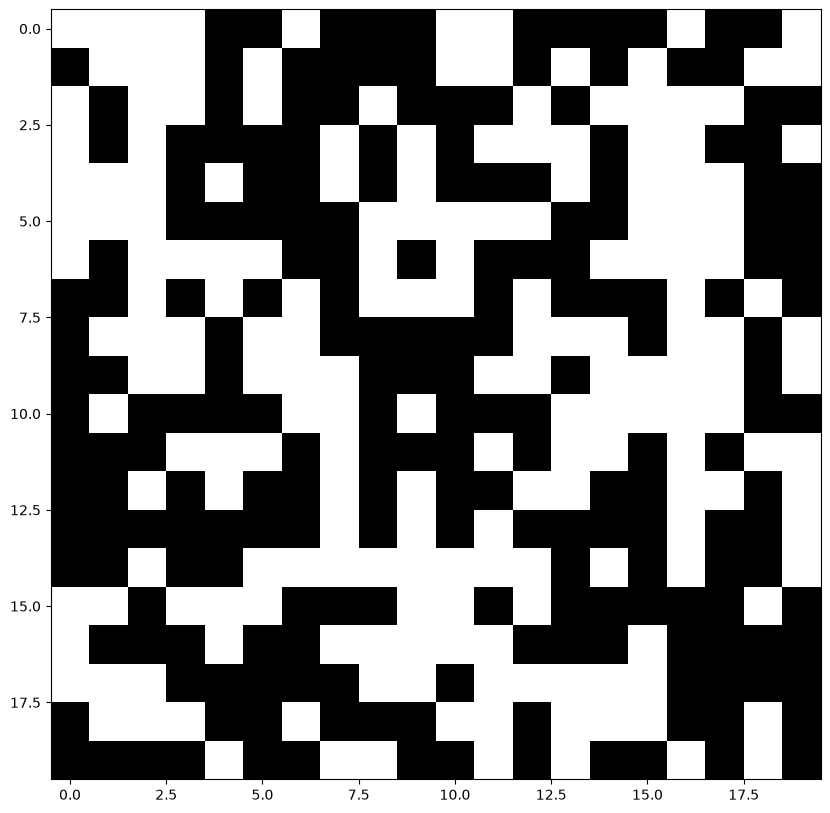

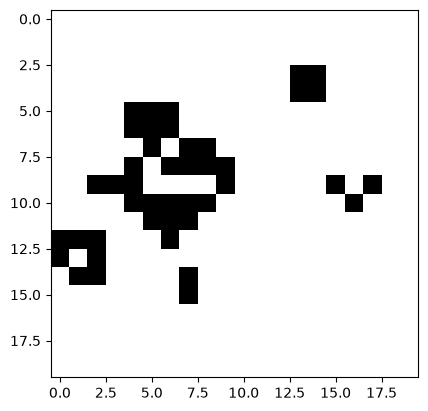

In [7]:
# CHECK IF THE RULE CHANGER WORKS
rule = 'Moore'
path = 'data_moore/gof_moore'
run_CA(model, generations, width, height, save_image, save_video, save_data, path, rule)

MovieWriter imagemagick unavailable; using Pillow instead.


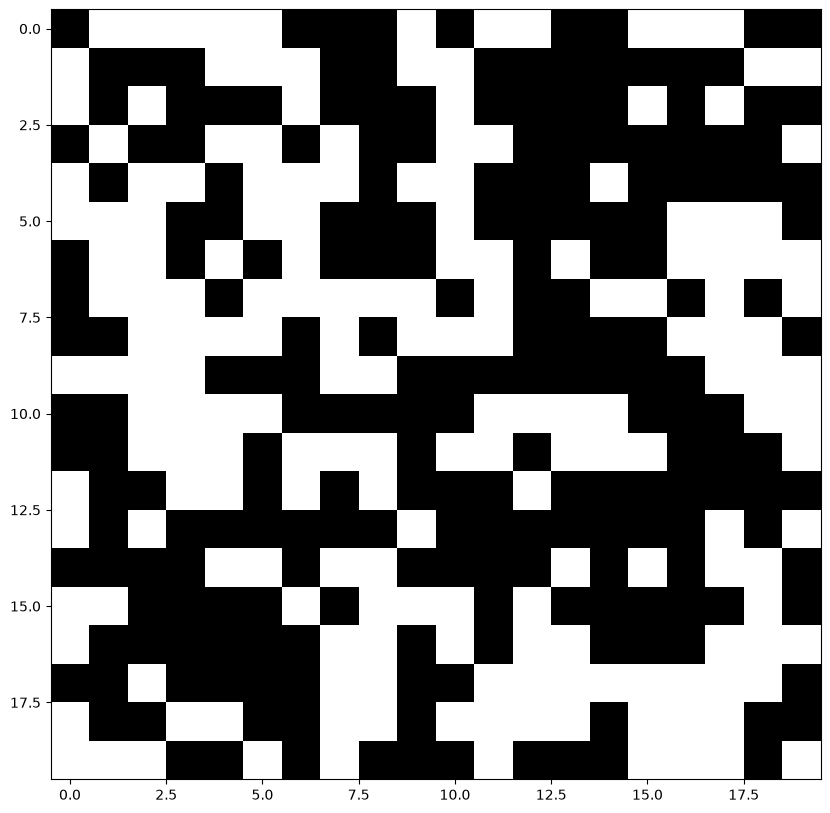

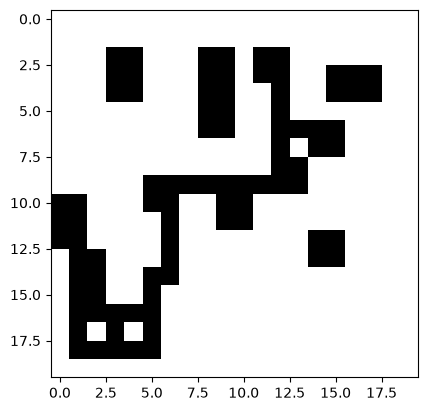

In [8]:
rule = "VN"
path = 'data_vn/gof_vn'
run_CA(model, generations, width, height, save_image, save_video, save_data, path, rule)

WE MAY HAVE A MOVIOLA!

now we should gain the informations... we should use data or we can use the gift?
Don't know, maybe we should use the data, it's easy and customizable

# FRAME IMAGE CONVERTER 

In [9]:
# generate dinamically the path!!

data = np.load("data_moore/gof_moore.npy")

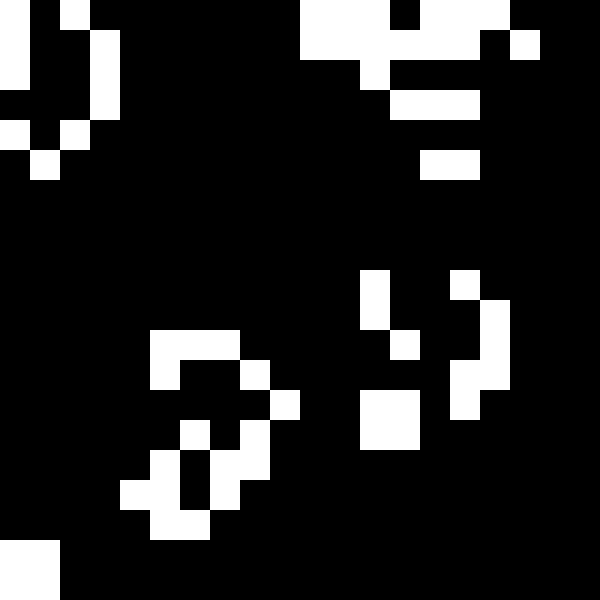

In [13]:

frame = convert_to_image(data, 10)
display(frame.resize((600, 600), Image.Resampling.NEAREST))

# GAINING DATA FROM EXPERIMENTS

In [14]:
data = data_obtainer("data_moore/gof_moore.gif", "moore")

In [ ]:
data = data_obtainer("data_vn/gof_vn.gif", "vn")

# pensiamo a come andare avanti

ha senso suddividere il dataset in coppie di frame, (F0,F1) (F1,F2) (F2,F3) e dare in pasto il tutto ad una CNN